In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dt=pd.read_csv("loan_approval_dataset.csv")

In [3]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Selection 1: Data Understanding

In [4]:
#Are there missing values in the dataset?? which columns are most affected?
dt.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [5]:
#data sctructure
#what are the data types of each feature (categorical vs numerical)
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
#summary statistics
dt.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
#change the value of the all the numeric columns of the dataframe upto 2 point decimal
pd.set_option('display.float_format','{:.2f}'.format)

In [8]:
dt.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [9]:
#how many loan applications are there in this dataset
dt['loan_id'].count()

4269

In [10]:
#strip out the white space from both sides

dt.columns=dt.columns.str.strip()

In [11]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [12]:
dt.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [13]:
dt[['education', 'self_employed',
      'loan_status']]=(dt[['education', 'self_employed',
       'loan_status']].apply(lambda x:x.str.strip()))

In [14]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [15]:
dt['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [16]:
#what percentage of the applications get loan approved vs rejected
dt['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [17]:
dt['loan_status'].value_counts(normalize=True)*100

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64

In [18]:
# change datatype of "loan_id" column

dt['loan_id']=dt['loan_id'].astype(str)

In [19]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


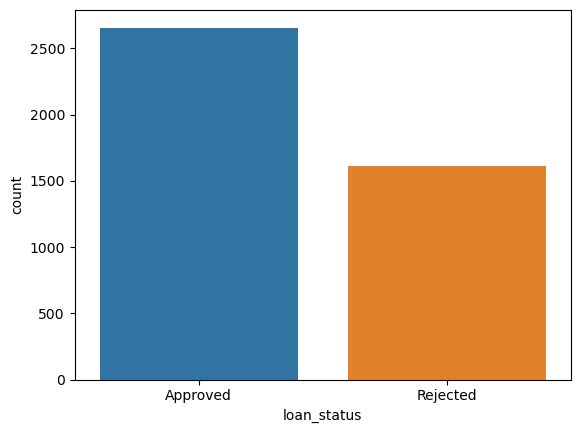

In [20]:
#is the dataset balanced or imbalanced for loan approval
sns.countplot(x='loan_status', data=dt)
plt.show()

# Section 2 : Exploratory Data Analysis(EDA)

### Does employment type affect loan approval?


In [21]:
dt["self_employed"].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [22]:
#  emp_status=dt.groupby(['self_employed','loan_status'])['loan_status'].count().unstack()
#  emp_status['Total']= emp_status['Approved']+emp_status['Rejected']
# emp_status['Approval_%'] = emp_status['Approved'] / emp_status['Total']*100


In [23]:
emp_status = pd.crosstab(dt['self_employed'], dt['loan_status'])
emp_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [24]:
emp_status['Total'] = emp_status.sum(axis=1) # emp_status['Approved']+emp_status['Rejected']
emp_status['Approval_%'] = emp_status['Approved'] / emp_status['Total'] * 100
#this is percentage

In [25]:
emp_status

loan_status,Approved,Rejected,Total,Approval_%
self_employed,,,,
No,1318,801,2119,62.20
Yes,1338,812,2150,62.23


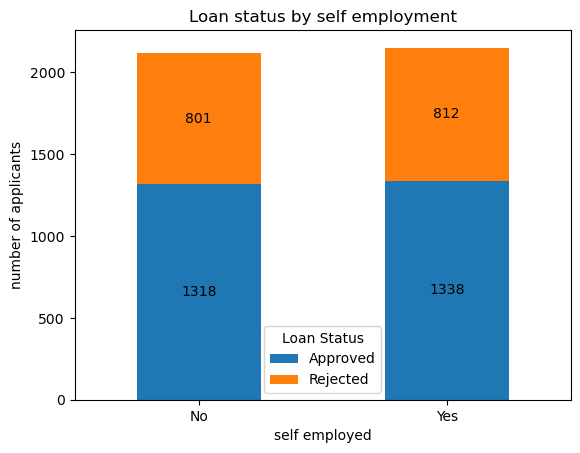

In [26]:
#plot stacked bar chart
# ax - matplotlib axes object(the chart area)
ax = emp_status[['Approved','Rejected']].plot(kind='bar',stacked=True)
plt.title("Loan status by self employment")
plt.xlabel("self employed")
plt.ylabel("number of applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax.containers :
     ax.bar_label(container, label_type='center')
     
plt.show()

#### => The approval rate for self-employed and non-self-employed applicants is nearly similar. Therefore, employment type does not significantly affect loan approval.

### Do graduates get higher approval rate than non graduates?




In [27]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [28]:
gra_status= pd. crosstab(dt['education'], dt['loan_status'])
gra_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [29]:
gra_status['Total']=gra_status['Approved']+gra_status['Rejected']
gra_status["approval_%"]= gra_status['Approved']/gra_status['Total']*100
gra_status

loan_status,Approved,Rejected,Total,approval_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


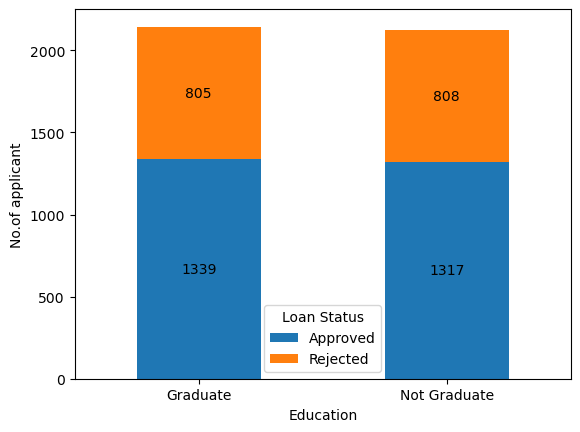

In [30]:
bx= gra_status[['Approved','Rejected']].plot(kind='bar',stacked=True)
plt.xticks(rotation=0)
plt.xlabel("Education")
plt.ylabel("No.of applicant")
plt.legend(title= "Loan Status")
for container in bx.containers:
    bx.bar_label(container, label_type='center')
plt.show()

#### => The loan approval rate for graduates (62.45%) is slightly higher than for non-graduates (61.98%). However, the difference of 0.47% is minimal. Therefore, education level does not appear to significantly influence loan approval decisions.

###  Does having more dependents reduce approval chances?

In [31]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [32]:
dt['no_of_dependents'].unique()

array([2, 0, 3, 5, 4, 1], dtype=int64)

In [33]:
dep=pd.crosstab(dt['no_of_dependents'],dt['loan_status'])
dep

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [34]:
dep['total']=dep['Approved'] + dep['Rejected']
dep['approval%']= dep['Approved']/dep['total']*100
dep

loan_status,Approved,Rejected,total,approval%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


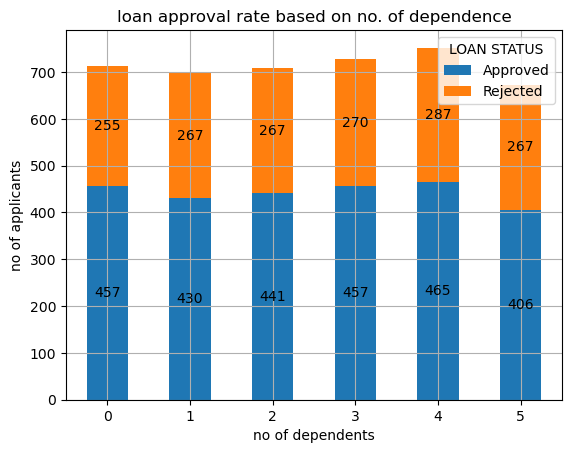

In [35]:

ax1=dep[['Approved','Rejected']].plot(kind='bar',stacked=True)
plt.xticks(rotation=0)
plt.legend(title='LOAN STATUS')
plt.title('loan approval rate based on no. of dependence')
plt.xlabel("no of dependents")
plt.ylabel("no of applicants")
plt.grid(True)
for container in ax1.containers:
    ax1.bar_label(container, label_type='center')
plt.show()

#### The approval percentage remains relatively stable across different numbers of dependents (around 60–64%). Although applicants with zero dependents have slightly higher approval rates, the variation is small. Therefore, number of dependents does not significantly reduce loan approval chances based on this dataset.


### What is the relationship between applicant income and loan approval?


In [36]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [37]:
dt['income_annum'].describe()

count      4269.00
mean    5059123.92
std     2806839.83
min      200000.00
25%     2700000.00
50%     5100000.00
75%     7500000.00
max     9900000.00
Name: income_annum, dtype: float64

In [38]:
x=dt.groupby(by=['loan_status'])['income_annum'].mean(numeric_only=True)
x

loan_status
Approved   5025903.61
Rejected   5113825.17
Name: income_annum, dtype: float64

In [39]:
type(x)

pandas.core.series.Series

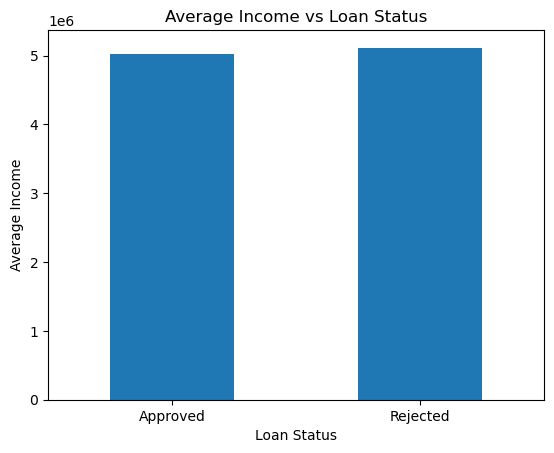

In [40]:
ax2= x.plot(kind='bar',stacked= True )
plt.xticks(rotation=0)
plt.xlabel("Loan Status")
plt.ylabel("Average Income")
plt.title("Average Income vs Loan Status")
plt.show()

#### From the analysis, the average annual income of rejected applicants (₹5,113,825) is slightly higher than that of approved applicants (₹5,025,903). Since the difference is minimal, it can be concluded that there is no significant relationship between income and loan approval in this dataset.

### How does loan amount vary between approved and rejected loans?

In [41]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [42]:
dt['loan_amount'].describe()

count       4269.00
mean    15133450.46
std      9043362.98
min       300000.00
25%      7700000.00
50%     14500000.00
75%     21500000.00
max     39500000.00
Name: loan_amount, dtype: float64

In [43]:
dt.groupby('loan_status')['loan_amount'].mean(numeric_only=True)

loan_status
Approved   15247251.51
Rejected   14946063.24
Name: loan_amount, dtype: float64

In [44]:
approved_amount=dt[dt['loan_status']=='Approved']['loan_amount']

In [45]:

rejected_amount=dt[dt['loan_status']=='Rejected']['loan_amount']

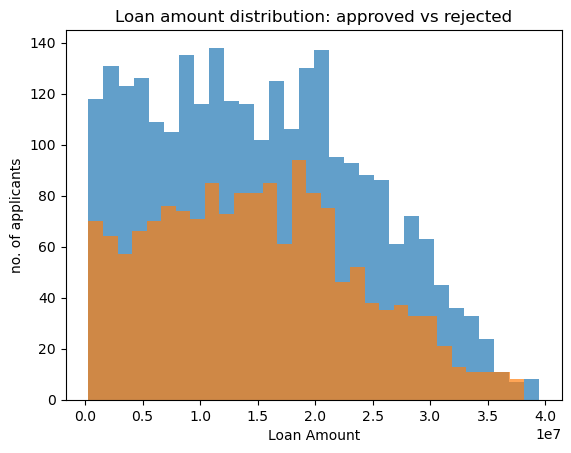

In [46]:
#plot hist
plt.hist(approved_amount,bins=30 , alpha=0.7, label='Approved')
plt.hist(rejected_amount,bins=30 , alpha=0.7, label='Rejected')
plt.xticks(rotation=0)
plt.xlabel("Loan Amount")
plt.ylabel("no. of applicants")
plt.title("Loan amount distribution: approved vs rejected")
plt.show()

#### The average income of approved applicants (₹15,247,251) is slightly higher than that of rejected applicants (₹14,946,063). However, the difference is relatively small. Therefore, income shows only a weak positive relationship with loan approval and is not a strong determining factor by itself.

### Does Cibil Score strongly influence loan approval?

In [47]:

dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [48]:
dt['cibil_score'].describe()

count   4269.00
mean     599.94
std      172.43
min      300.00
25%      453.00
50%      600.00
75%      748.00
max      900.00
Name: cibil_score, dtype: float64

In [49]:
dt.groupby('loan_status')['cibil_score'].mean(numeric_only=True)

loan_status
Approved   703.46
Rejected   429.47
Name: cibil_score, dtype: float64

In [50]:
approved_cibil=dt[dt['loan_status']=='Approved']['cibil_score']
rejected_cibil=dt[dt['loan_status']=='Rejected']['cibil_score']

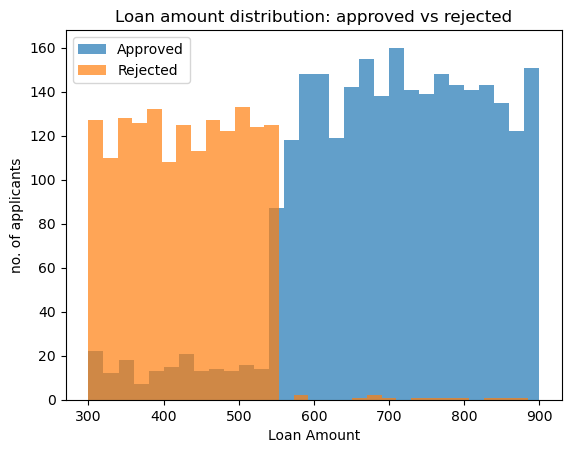

In [51]:
plt.hist(approved_cibil,bins=30 , alpha=0.7, label='Approved')
plt.hist(rejected_cibil,bins=30 , alpha=0.7, label='Rejected')
plt.xticks(rotation=0)
plt.xlabel("Loan Amount")
plt.ylabel("no. of applicants")
plt.title("Loan amount distribution: approved vs rejected")
plt.legend()
plt.show()

## Section 3: DATA VISUALIZATION

### Compare applicant income vs Loan amount (scatter plot)

In [52]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


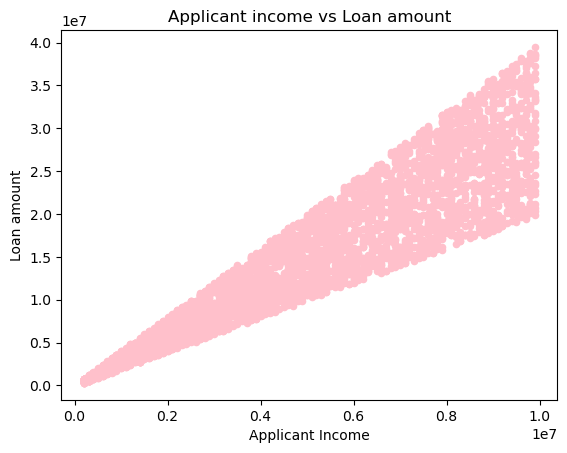

In [53]:

dt.plot(x='income_annum', y='loan_amount', kind='scatter', color='pink')
plt.title("Applicant income vs Loan amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan amount")
plt.show()

### Show correlation heatmap of numeric features

<function matplotlib.pyplot.show(close=None, block=None)>

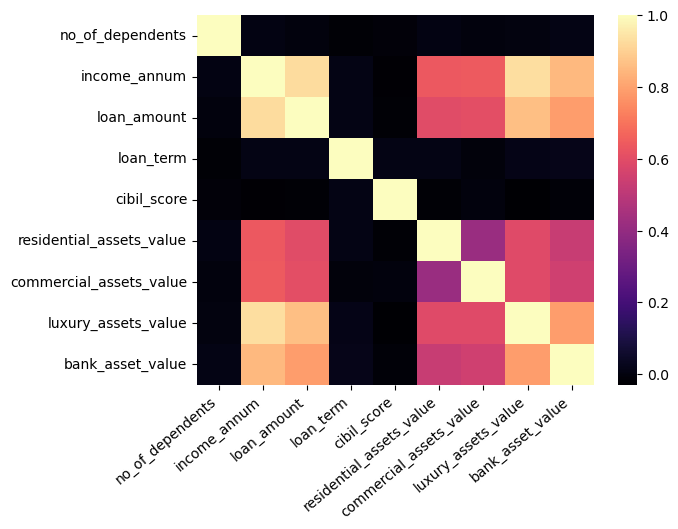

In [54]:
sns.heatmap(dt.corr(numeric_only=True),cmap='magma')
plt.xticks(rotation=40, ha='right')
plt.show

In [55]:
dt['loan_amount'].corr(dt['income_annum'])

0.927469910987149

In [56]:
dt['luxury_assets_value'].corr(dt['income_annum'])

0.9291454207522585

## Section 4: Data Cleaning and Feature Engineering

### Detect Outliers

###  Remove Outliers

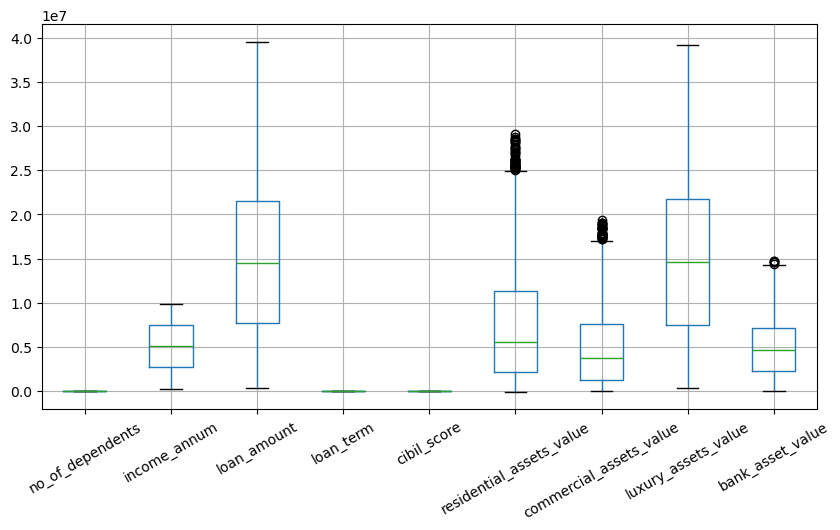

In [57]:
plt.figure(figsize=(10,5))
dt.boxplot()
plt.xticks(rotation=30)
plt.show()

<Axes: xlabel='residential_assets_value'>

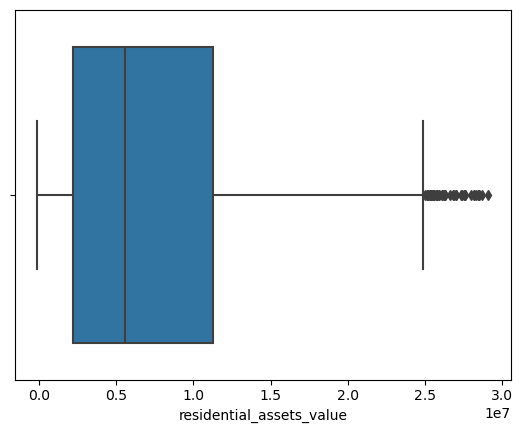

In [58]:
sns.boxplot(x="residential_assets_value", data=dt) 

In [59]:
#calculate quantile

q1=dt['residential_assets_value'].quantile(0.25)

q2=dt['residential_assets_value'].quantile(0.75)

#calculate iqr
IQR= q2-q1

In [60]:
IQR


9100000.0

In [61]:
lower_limit= q1-1.5*IQR
upper_limit = q2+1.5*IQR

In [62]:
dt=dt[(dt['residential_assets_value']>=lower_limit)&(dt['residential_assets_value']<=upper_limit)]
dt
#remove outliner

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


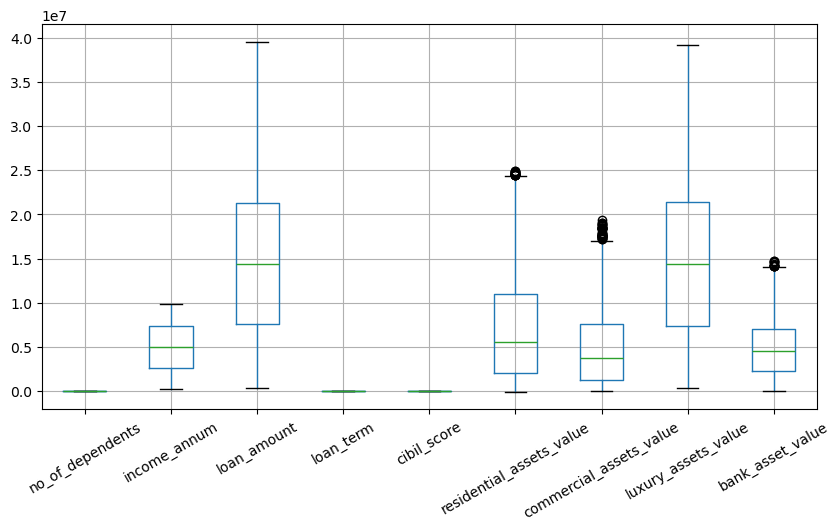

In [63]:
plt.figure(figsize=(10,5))
dt.boxplot()
plt.xticks(rotation=30)
plt.show()

In [64]:
Rq1=dt['commercial_assets_value'].quantile(0.25)
Rq2= dt['commercial_assets_value'].quantile(0.75)
R_iqr=Rq2-Rq1
R_iqr

6300000.0

In [65]:
max_lim= Rq2+1.5*R_iqr
min_lim= Rq1-1.5*R_iqr
max_lim, min_lim

(17050000.0, -8150000.0)

In [66]:
dt=dt[(dt['commercial_assets_value']>= min_lim )& (dt['commercial_assets_value']<= max_lim )]
dt

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


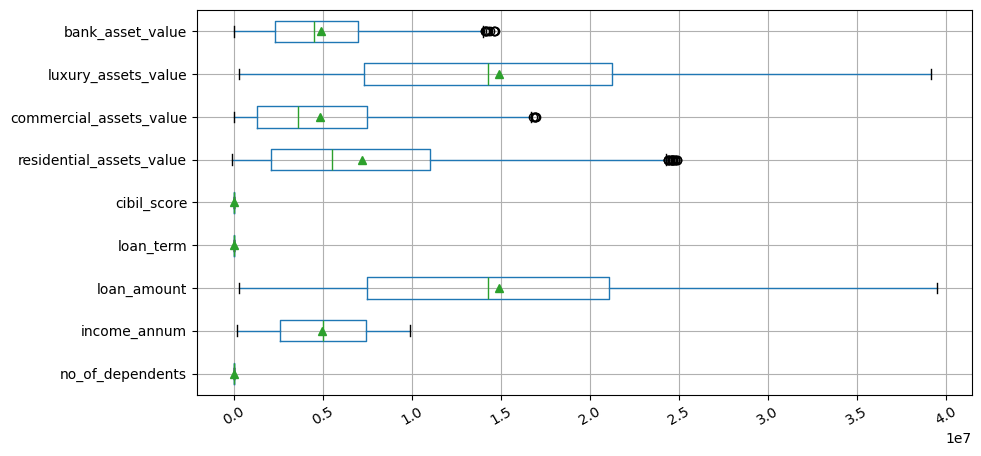

In [67]:
plt.figure(figsize=(10,5))
dt.boxplot(showmeans= True, vert= False)
plt.xticks(rotation=30)
plt.show()

In [68]:
qq1=dt['bank_asset_value'].quantile(0.25)
qq2= dt['bank_asset_value'].quantile(0.75)
q_iqr=qq2-qq1
q_iqr

4700000.0

In [69]:
max_limq= qq2+1.5*q_iqr
min_limq= qq1-1.5*q_iqr
max_limq, min_limq

(14050000.0, -4750000.0)

In [70]:
dt=dt[(dt['bank_asset_value']>= min_limq )& (dt['bank_asset_value']<= max_limq )]
dt

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


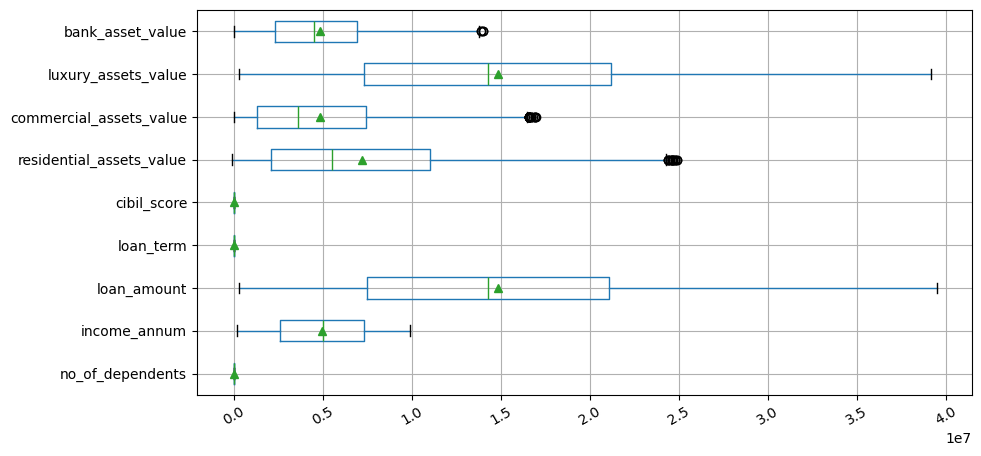

In [71]:
plt.figure(figsize=(10,5))
dt.boxplot(showmeans= True, vert= False)
plt.xticks(rotation=30)
plt.show()

###  which features should be dropped (like Loan_ID)?

In [72]:
dt.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [73]:
dt.drop('loan_id', inplace= True, axis=1)
dt


C:\Users\sangj\AppData\Local\Temp\ipykernel_19416\1730257977.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt.drop('loan_id', inplace= True, axis=1)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


### 4️ Convert Categorical Variables into Numeric

### A) Mapping (Binary Encoding)

In [74]:
dt.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [75]:
dt['loan_status']=dt['loan_status'].map({'Approved': 1 , 'Rejected':0})


C:\Users\sangj\AppData\Local\Temp\ipykernel_19416\3385375435.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt['loan_status']=dt['loan_status'].map({'Approved': 1 , 'Rejected':0})


In [76]:
dt

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


### B) Label Encoding (Level Encoding)

In [77]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
dt['self_employed']=le.fit_transform(dt['self_employed'])

C:\Users\sangj\AppData\Local\Temp\ipykernel_19416\2177159362.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dt['self_employed']=le.fit_transform(dt['self_employed'])


In [78]:
dt

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


###  C) One-Hot Encoding

In [79]:
dt.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0


In [80]:

dt = pd.get_dummies(dt, columns=['education'], drop_first=True)
# this help to avoid the dummy variable trap and keep the model clean

In [81]:
dt

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,True


In [82]:
dt['education_Not Graduate'] = dt['education_Not Graduate'].astype(int)

In [83]:
dt

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,0
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,1
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,1
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,1


## Scale Numerical Features Before Model Training

 feature scaling is essential for model like logistic regression and svm, but not required for free based models. howeveer i applied scaling to ensure consistency and fair model comparison

In [84]:
# from sklearn.preprocessing import StandardScaler

In [85]:
# scaler= StandardScaler()
# num_cols=['income_annum', 'loan_amount',
#        'loan_term', 'cibil_score', 'residential_assets_value',
#        'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

In [86]:
# dt[num_cols]=scaler.fit_transform(dt[num_cols])

In [87]:
# dt

## Model Building/

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

x=dt.drop('loan_status', axis=1)
y= dt['loan_status']

x_train,x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)

models={"LogisticRegression": LogisticRegression(max_iter =1000),
       "DecisionTreeClassifier":DecisionTreeClassifier(),
       "RandomForestClassifier": RandomForestClassifier()
       }

for name, model in models.items():
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    print(name, "Accuracy", accuracy_score(y_test, preds)*100)


LogisticRegression Accuracy 81.19760479041916
DecisionTreeClassifier Accuracy 97.60479041916167
RandomForestClassifier Accuracy 98.44311377245509


In [89]:
# step 1: split features and target
x=dt.drop('loan_status', axis=1)
y= dt['loan_status']

In [90]:
#step2: train-test split
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)


In [91]:
#step3 : Build Random Forest Model

from sklearn.ensemble import RandomForestClassifier
rdc= RandomForestClassifier(n_estimators=200, max_depth=10, random_state=39)



In [92]:
rdc.fit(x_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
#step4: make predictions
y_pred=rdc.predict(x_test)


In [94]:
#step 5: evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Acuuracy: ", accuracy_score(y_test, y_pred)*100,"%")
print("Classification Report: ", classification_report(y_test, y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred))

Acuuracy:  97.8443113772455 %
Classification Report:                precision    recall  f1-score   support

           0       0.98      0.96      0.97       315
           1       0.98      0.99      0.98       520

    accuracy                           0.98       835
   macro avg       0.98      0.97      0.98       835
weighted avg       0.98      0.98      0.98       835

Confusion Matrix:  [[302  13]
 [  5 515]]


In [95]:
# step 6: Feature importance

fr=pd.Series(rdc.feature_importances_, index=x.columns).sort_values(ascending=False)
fr

cibil_score                0.83
loan_term                  0.06
loan_amount                0.02
income_annum               0.02
luxury_assets_value        0.02
residential_assets_value   0.01
commercial_assets_value    0.01
bank_asset_value           0.01
no_of_dependents           0.01
self_employed              0.00
education_Not Graduate     0.00
dtype: float64

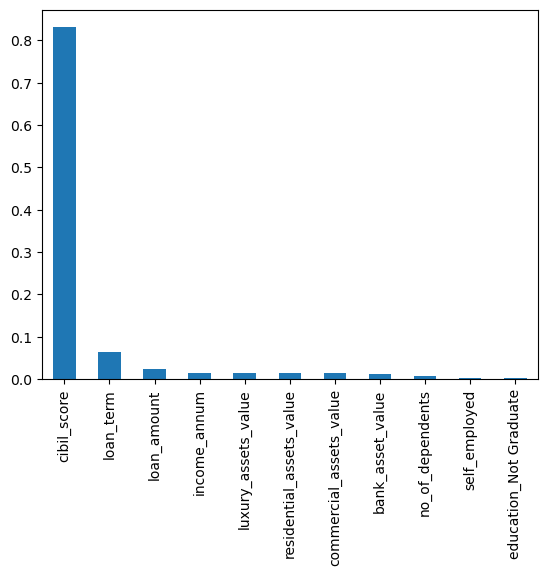

In [96]:
fr.plot(kind='bar')
plt.show()

## Model Prediction

In [97]:
dt.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,0


In [102]:
#for a new customer

new_applicant={
    'no_of_dependents':4,
    'self_employed':1,
    'income_annum': 600000,
    'loan_amount': 2500000,
    'loan_term': 36,
    'cibil_score': 600,
    'residential_assets_value': 300000,
    'commercial_assets_value':0,
    'luxury_assets_value':0,
    'bank_asset_value': 5000,
    'education_Not Graduate': 1   
}

new_df= pd.DataFrame([new_applicant])

In [103]:
new_df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Not Graduate
0,4,1,600000,2500000,36,600,300000,0,0,5000,1


In [104]:
prd=rdc.predict(new_df)

In [106]:
prd # this array([1] ) means the the loan will be approved and 
# if it is arr[0] that means it will not be approved now if we change the 
# cibil_score value to low then it returns arr[0] means loan not approved
# and if the cibil_score is high it returns arr[1] means loan approved

array([1], dtype=int64)

## Save model

In [107]:
import joblib
joblib.dump(rdc, 'loan_approval_prediction.pkl')

['loan_approval_prediction.pkl']

In [108]:
#load the model and use

loaded_model=joblib.load('loan_approval_prediction.pkl')

In [109]:
loaded_model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Load the Model

If you saved using pickle:

import pickle

with open("loan_approval_prediction.pkl", "rb") as f:
    model = pickle.load(f)

Now model is your trained model.

In [111]:
#for future predictions
#prediction = model.predict(new_df)
#print(prediction)